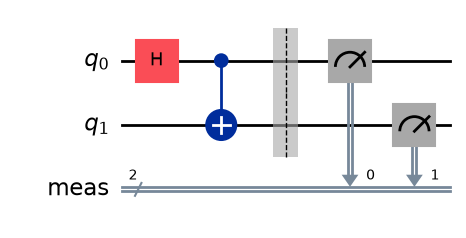

In [1]:
from qiskit import QuantumCircuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

In [2]:
from dotenv import load_dotenv
import os
from iqm.qiskit_iqm import IQMProvider

def get_backend():
    load_dotenv("token.env")
    os.environ["IQM_TOKEN"] = os.getenv("IQM_TOKEN")
    server_url = os.getenv("SERVER")
    provider = IQMProvider(server_url)
    backend = provider.get_backend()
    return backend

/home/gciapa/miniconda3/envs/qml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Progress in queue:   0%|          | 0/1 [00:02<?, ?it/s]

Counts for custom circuit: {'00': 494, '11': 479, '01': 27, '10': 24}
5f93a0b4-1a73-4f39-a187-bdcb7c811665


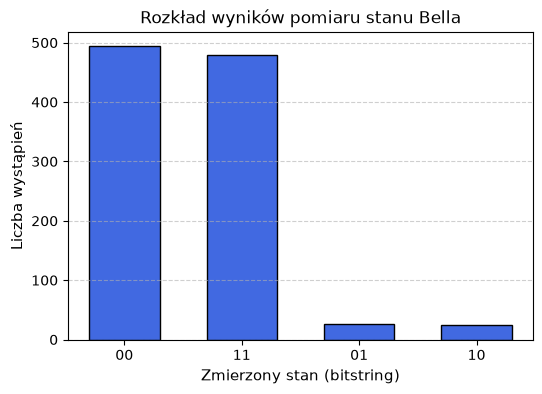

In [5]:
import matplotlib.pyplot as plt

from qiskit import transpile
backend = get_backend()
bell_transp = transpile(bell, backend=backend, optimization_level=3)

job = backend.run([bell_transp], shots=1024)
job_result = job.result()


counts = job.result().get_counts()
print(f"Counts for custom circuit: {counts}")
print(job.result().parameters.calibration_set_id)

states = list(counts.keys())
occurrences = list(counts.values())

plt.figure(figsize=(6, 4))
plt.bar(states, occurrences, color="royalblue", edgecolor="black", width=0.6)
plt.title("Rozkład wyników pomiaru stanu Bella", fontsize=12)
plt.xlabel("Zmierzony stan (bitstring)", fontsize=11)
plt.ylabel("Liczba wystąpień", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()